In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 

In [2]:
df = pd.read_csv('D:\ML\EDA\heart_disease.csv')

In [3]:
df.head()

,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,56.0,Male,153.0,155.0,High,Yes,Yes,No,24.991591,Yes,...,No,High,Medium,7.633228,Medium,342.0,NaN,12.969246,12.387250,No
1,69.0,Female,146.0,286.0,High,No,Yes,Yes,25.221799,No,...,No,Medium,High,8.744034,Medium,133.0,157.0,9.355389,19.298875,No
2,46.0,Male,126.0,216.0,Low,No,No,No,29.855447,No,...,Yes,Low,Low,4.440440,Low,393.0,92.0,12.709873,11.230926,No
3,32.0,Female,122.0,293.0,High,Yes,Yes,No,24.130477,Yes,...,Yes,Low,High,5.249405,High,293.0,94.0,12.509046,5.961958,No
4,60.0,Male,166.0,242.0,Low,Yes,Yes,Yes,20.486289,Yes,...,No,Low,High,7.030971,High,263.0,154.0,10.381259,8.153887,No


In [4]:
df.shape

(10000, 21)

In [5]:
df.describe()

,Age,Blood Pressure,Cholesterol Level,BMI,Sleep Hours,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level
count,9971.000000,9981.000000,9970.000000,9978.000000,9975.000000,9974.000000,9978.000000,9974.000000,9980.000000
mean,49.296259,149.757740,225.425577,29.077269,6.991329,250.734409,120.142213,7.472201,12.456271
std,18.193970,17.572969,43.575809,6.307098,1.753195,87.067226,23.584011,4.340248,4.323426
min,18.000000,120.000000,150.000000,18.002837,4.000605,100.000000,80.000000,0.003647,5.000236
25%,34.000000,134.000000,187.000000,23.658075,5.449866,176.000000,99.000000,3.674126,8.723334
50%,49.000000,150.000000,226.000000,29.079492,7.003252,250.000000,120.000000,7.472164,12.409395
75%,65.000000,165.000000,263.000000,34.520015,8.531577,326.000000,141.000000,11.255592,16.140564
max,80.000000,180.000000,300.000000,39.996954,9.999952,400.000000,160.000000,14.997087,19.999037


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   9971 non-null   float64
 1   Gender                9981 non-null   object 
 2   Blood Pressure        9981 non-null   float64
 3   Cholesterol Level     9970 non-null   float64
 4   Exercise Habits       9975 non-null   object 
 5   Smoking               9975 non-null   object 
 6   Family Heart Disease  9979 non-null   object 
 7   Diabetes              9970 non-null   object 
 8   BMI                   9978 non-null   float64
 9   High Blood Pressure   9974 non-null   object 
 10  Low HDL Cholesterol   9975 non-null   object 
 11  High LDL Cholesterol  9974 non-null   object 
 12  Alcohol Consumption   7414 non-null   object 
 13  Stress Level          9978 non-null   object 
 14  Sleep Hours           9975 non-null   float64
 15  Sugar Consumption   

In [7]:
df.isnull().sum()

Age                       29
Gender                    19
Blood Pressure            19
Cholesterol Level         30
Exercise Habits           25
Smoking                   25
Family Heart Disease      21
Diabetes                  30
BMI                       22
High Blood Pressure       26
Low HDL Cholesterol       25
High LDL Cholesterol      26
Alcohol Consumption     2586
Stress Level              22
Sleep Hours               25
Sugar Consumption         30
Triglyceride Level        26
Fasting Blood Sugar       22
CRP Level                 26
Homocysteine Level        20
Heart Disease Status       0
dtype: int64

In [8]:
df['Alcohol Consumption'].unique()

array(['High', 'Medium', 'Low', nan], dtype=object)

In [9]:
from sklearn.preprocessing import OneHotEncoder

In [10]:
encoder = OneHotEncoder(sparse_output=False)

In [11]:
df.head(2)

,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,56.0,Male,153.0,155.0,High,Yes,Yes,No,24.991591,Yes,...,No,High,Medium,7.633228,Medium,342.0,NaN,12.969246,12.387250,No
1,69.0,Female,146.0,286.0,High,No,Yes,Yes,25.221799,No,...,No,Medium,High,8.744034,Medium,133.0,157.0,9.355389,19.298875,No


In [12]:
df['Alcohol Consumption'].unique()

array(['High', 'Medium', 'Low', nan], dtype=object)

In [13]:
encoder.fit_transform(
df[['Gender','Exercise Habits','Smoking','Family Heart Disease','Diabetes','High Blood Pressure']])

array([[0., 1., 0., ..., 0., 1., 0.],
       [1., 0., 0., ..., 1., 0., 0.],
       [0., 1., 0., ..., 1., 0., 0.],
       ...,
       [0., 1., 0., ..., 1., 0., 0.],
       [0., 1., 0., ..., 0., 1., 0.],
       [1., 0., 0., ..., 1., 0., 0.]], shape=(10000, 19))

In [14]:
encoded_df = pd.DataFrame(
    encoder.fit_transform(df[['Gender','Exercise Habits','Smoking','Family Heart Disease','Diabetes','High Blood Pressure']]),
    columns= encoder.get_feature_names_out(['Gender','Exercise Habits','Smoking','Family Heart Disease','Diabetes','High Blood Pressure'])
)

In [15]:
df = pd.concat([df, encoded_df], axis=1)
df.head()

,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,Smoking_nan,Family Heart Disease_No,Family Heart Disease_Yes,Family Heart Disease_nan,Diabetes_No,Diabetes_Yes,Diabetes_nan,High Blood Pressure_No,High Blood Pressure_Yes,High Blood Pressure_nan
0,56.0,Male,153.0,155.0,High,Yes,Yes,No,24.991591,Yes,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,69.0,Female,146.0,286.0,High,No,Yes,Yes,25.221799,No,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
2,46.0,Male,126.0,216.0,Low,No,No,No,29.855447,No,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,32.0,Female,122.0,293.0,High,Yes,Yes,No,24.130477,Yes,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4,60.0,Male,166.0,242.0,Low,Yes,Yes,Yes,20.486289,Yes,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [16]:
df.drop(['Gender','Exercise Habits','Smoking','Family Heart Disease','Diabetes','High Blood Pressure'], axis=1, inplace=True)

In [17]:
df.tail()

,Age,Blood Pressure,Cholesterol Level,BMI,Low HDL Cholesterol,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,...,Smoking_nan,Family Heart Disease_No,Family Heart Disease_Yes,Family Heart Disease_nan,Diabetes_No,Diabetes_Yes,Diabetes_nan,High Blood Pressure_No,High Blood Pressure_Yes,High Blood Pressure_nan
9995,25.0,136.0,243.0,18.788791,No,Yes,Medium,High,6.834954,Medium,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
9996,38.0,172.0,154.0,31.856801,No,Yes,NaN,High,8.247784,Low,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
9997,73.0,152.0,201.0,26.899911,Yes,Yes,NaN,Low,4.436762,Low,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
9998,23.0,142.0,299.0,34.964026,No,Yes,Medium,High,8.526329,Medium,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
9999,38.0,128.0,193.0,25.111295,Yes,Yes,High,Medium,5.659394,High,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0


In [18]:
df.isnull().sum()

Age                           29
Blood Pressure                19
Cholesterol Level             30
BMI                           22
Low HDL Cholesterol           25
High LDL Cholesterol          26
Alcohol Consumption         2586
Stress Level                  22
Sleep Hours                   25
Sugar Consumption             30
Triglyceride Level            26
Fasting Blood Sugar           22
CRP Level                     26
Homocysteine Level            20
Heart Disease Status           0
Gender_Female                  0
Gender_Male                    0
Gender_nan                     0
Exercise Habits_High           0
Exercise Habits_Low            0
Exercise Habits_Medium         0
Exercise Habits_nan            0
Smoking_No                     0
Smoking_Yes                    0
Smoking_nan                    0
Family Heart Disease_No        0
Family Heart Disease_Yes       0
Family Heart Disease_nan       0
Diabetes_No                    0
Diabetes_Yes                   0
Diabetes_n

In [19]:
print(f"The skew value of Age :", df['Age'].skew())
print(f"The skew value of Blood Pressure :", df['Blood Pressure'].skew())
print(f"The skew value of Cholesterol Level :", df['Cholesterol Level'].skew())
print(f"The skew value of BMI  :", df['BMI'].skew())
print(f"The skew value of Sleep Hours:", df['Sleep Hours'].skew())
print(f"The skew value of Triglyceride Level :", df['Triglyceride Level'].skew())
print(f"The skew value of Fasting Blood Sugar:", df['Fasting Blood Sugar'].skew())
print(f"The skew value of CRP Level:", df['CRP Level'].skew())
print(f"The skew value of Homocysteine Level:", df['Homocysteine Level'].skew())

The skew value of Age : -0.006789078660337985
The skew value of Blood Pressure : 0.013907286334450406
The skew value of Cholesterol Level : -0.007120157542554196
The skew value of BMI  : -0.021342412408070627
The skew value of Sleep Hours: 0.0001715222042222151
The skew value of Triglyceride Level : 0.006141871670865692
The skew value of Fasting Blood Sugar: -0.008914715496285058
The skew value of CRP Level: -0.004068719593602509
The skew value of Homocysteine Level: 0.007886281075255637


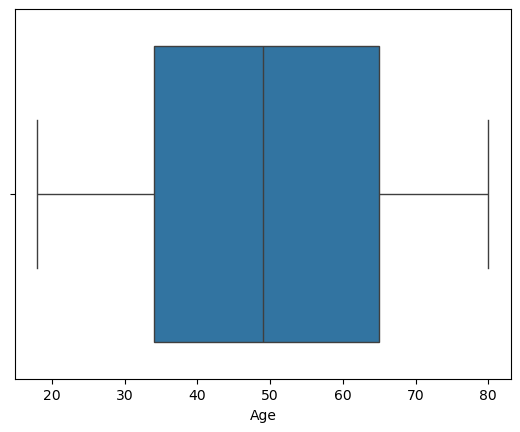

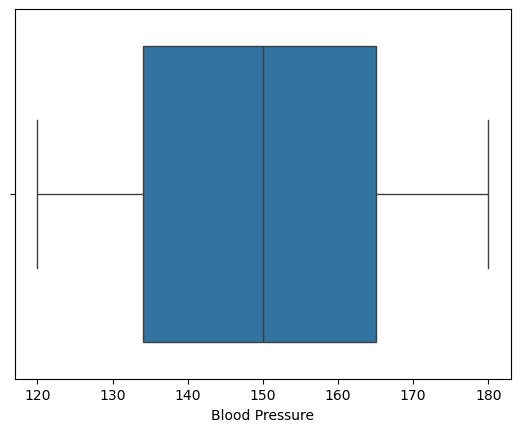

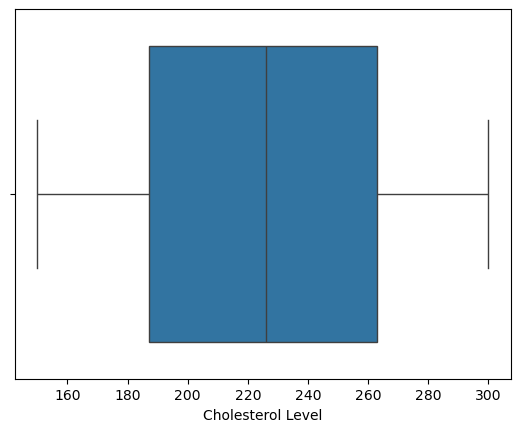

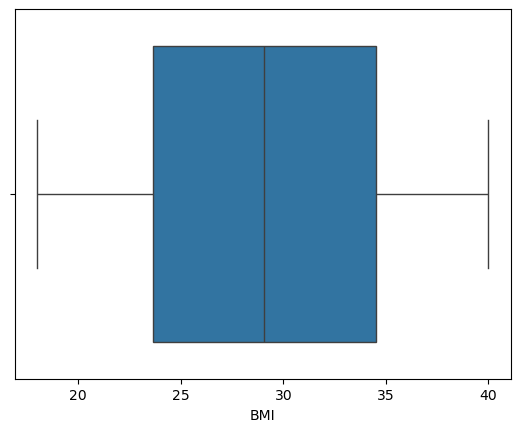

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = ['Age','Blood Pressure','Cholesterol Level','BMI']

for col in cols:
    sns.boxplot(x=df[col])
    plt.show()

In [21]:
df.isnull().mean()*100

Age                          0.29
Blood Pressure               0.19
Cholesterol Level            0.30
BMI                          0.22
Low HDL Cholesterol          0.25
High LDL Cholesterol         0.26
Alcohol Consumption         25.86
Stress Level                 0.22
Sleep Hours                  0.25
Sugar Consumption            0.30
Triglyceride Level           0.26
Fasting Blood Sugar          0.22
CRP Level                    0.26
Homocysteine Level           0.20
Heart Disease Status         0.00
Gender_Female                0.00
Gender_Male                  0.00
Gender_nan                   0.00
Exercise Habits_High         0.00
Exercise Habits_Low          0.00
Exercise Habits_Medium       0.00
Exercise Habits_nan          0.00
Smoking_No                   0.00
Smoking_Yes                  0.00
Smoking_nan                  0.00
Family Heart Disease_No      0.00
Family Heart Disease_Yes     0.00
Family Heart Disease_nan     0.00
Diabetes_No                  0.00
Diabetes_Yes  

In [22]:
df['Heart Disease Status'].value_counts()

Heart Disease Status
No     8000
Yes    2000
Name: count, dtype: int64

In [23]:
from sklearn.datasets import make_classification